Loaded train: (472432, 434)
After FE    : (472432, 526)
Numeric cols for correlation: 479

Top 30 features correlated with isFraud:

feature  correlation  abs_corr  pval
   V257     0.376922  0.376922   0.0
   V244     0.362693  0.362693   0.0
   V242     0.357924  0.357924   0.0
   V246     0.357095  0.357095   0.0
   V233     0.321014  0.321014   0.0
   V201     0.314536  0.314536   0.0
   V200     0.311494  0.311494   0.0
   V188     0.309743  0.309743   0.0
   V189     0.304461  0.304461   0.0
   V232     0.301770  0.301770   0.0
   V231     0.297559  0.297559   0.0
   V217     0.291612  0.291612   0.0
   V258     0.285164  0.285164   0.0
    V45     0.283103  0.283103   0.0
   V158     0.277668  0.277668   0.0
   V156     0.277487  0.277487   0.0
   V149     0.273709  0.273709   0.0
v4_mean     0.272682  0.272682   0.0
    V44     0.264049  0.264049   0.0
   V228     0.260285  0.260285   0.0
   V171     0.257362  0.257362   0.0
   V219     0.252700  0.252700   0.0
    V87     0.24

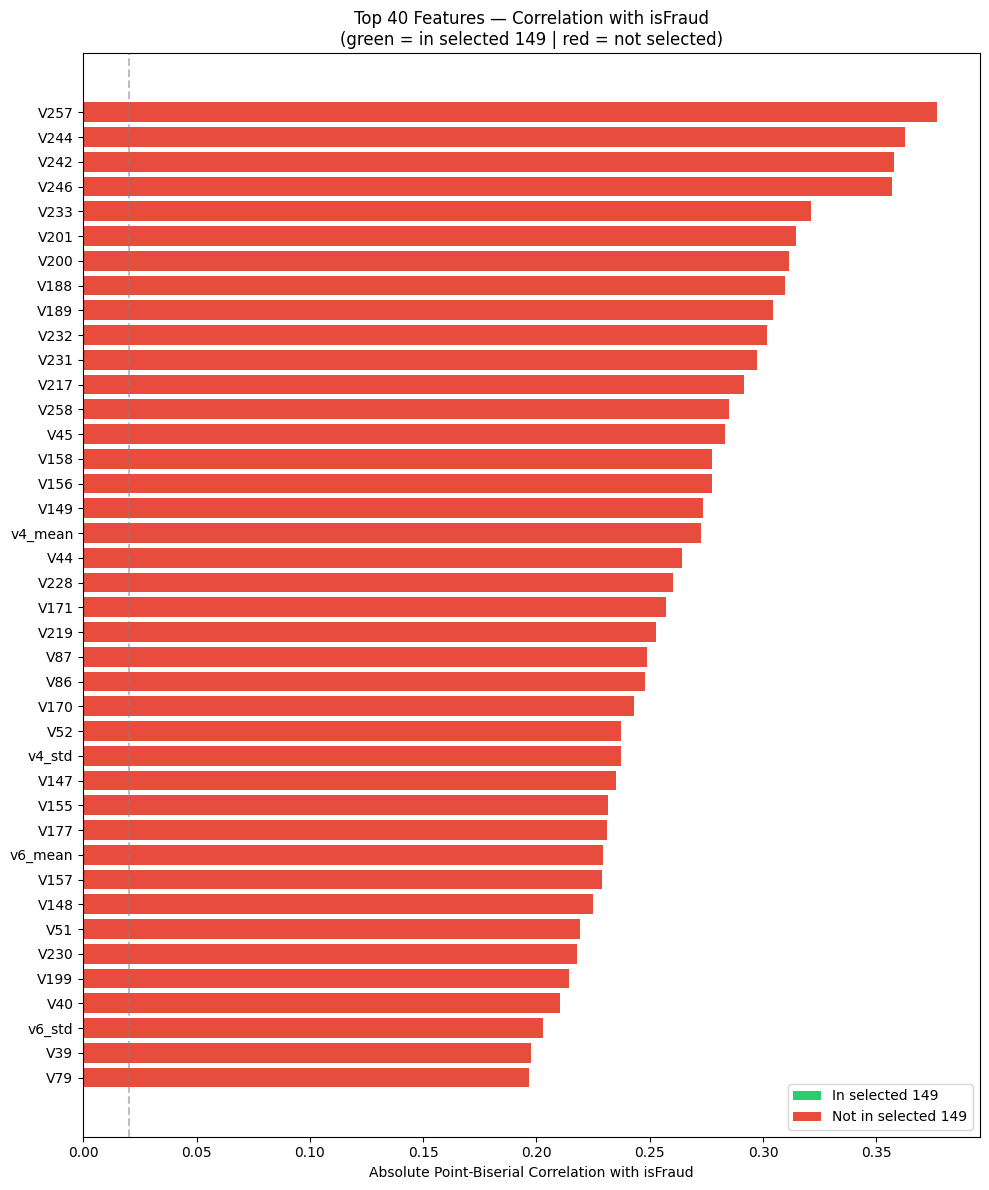

Plot saved → notebooks/EDA_output_Graphs/feature_correlation_isFraud.png
Table saved → notebooks/EDA_output_Graphs/feature_correlation_table.csv


In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL: Feature Correlation Analysis vs isFraud
# Run from: notebooks/03_feature_correlation.ipynb
# Purpose : Validate which features correlate with isFraud
#           so we can confirm the 149-col selection is justified
# ─────────────────────────────────────────────────────────────────

import sys
sys.path.append("..") # go up from notebooks/ to project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

from src.utils import feature_engineering

# ── 1. Load train parquet ─────────────────────────────────────────
train_df = pd.read_parquet("../artifacts/train.parquet")
print(f"Loaded train: {train_df.shape}")

# ── 2. Run feature engineering (same as pipeline) ─────────────────
train_df = feature_engineering(train_df, train_df=None)
print(f"After FE    : {train_df.shape}")

# ── 3. Separate numeric cols only (correlation needs numbers) ──────
drop_cols = ["isFraud", "TransactionID", "TransactionDT", "source"]
y = train_df["isFraud"]

numeric_df = train_df.drop(
    columns=[c for c in drop_cols if c in train_df.columns]
).select_dtypes(include=[np.number])

print(f"Numeric cols for correlation: {numeric_df.shape[1]}")

# ── 4. Point-biserial correlation vs isFraud ──────────────────────
# Point-biserial is correct for continuous vs binary target
# Pearson on binary target gives same result but pb is semantically right

results = []
for col in numeric_df.columns:
    valid = numeric_df[col].notna() & y.notna()
    if valid.sum() < 100: # skip cols with too few valid rows
        continue
    corr, pval = pointbiserialr(y[valid], numeric_df[col][valid])
    results.append({
        "feature"   : col,
        "correlation": round(corr, 6),
        "abs_corr"  : round(abs(corr), 6),
        "pval"      : round(pval, 6),
    })

corr_df = (
    pd.DataFrame(results)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

print(f"\nTop 30 features correlated with isFraud:\n")
print(corr_df.head(30).to_string(index=False))

# ── 5. Check where your 149 selected cols rank ────────────────────
selected_149 = [
    # label encode cols
    "ProductCD","card4","card6","DeviceType",
    "id_12","id_15","id_16","id_28","id_29",
    "id_35","id_36","id_37","id_38",
    "M1","M2","M3","M4","M5","M6","M7","M8","M9",
    # freq encode cols
    "card1","P_emaildomain","R_emaildomain",
    "id_30","id_31","id_33","DeviceInfo",
    "card1_addr1","card1_card2","card4_card6","card1_ProductCD",
    "addr1_addr2","P_R_email_match_domain",
    # key passthrough cols (abbreviated — add full list if needed)
    "TransactionAmt","card2","card3","card5",
    "addr1","addr2","dist1",
    "D1","D2","D4","D10","D11",
    "C1","C2","C3","C4","C5","C6","C7","C8","C9","C10","C11","C12","C13","C14",
    "TransactionAmt_Log","TransactionAmt_decimal","TransactionAmt_is_round",
    "Transaction_hour","Transaction_dow","Transaction_is_weekend",
    "V_sum_all","V_mean_all","V_std_all","V_nan_ratio",
    "v1_sum","v2_sum","v3_sum","v4_sum","v5_sum","v6_sum","v7_sum",
    "email_match","client_uid_freq","card1_freq",
]

selected_in_corr = corr_df[corr_df["feature"].isin(selected_149)]
not_in_selected  = corr_df[~corr_df["feature"].isin(selected_149)].head(20)

print(f"\n── Selected 149 cols — their correlation ranks ──")
print(f"Min abs_corr in selected : {selected_in_corr['abs_corr'].min():.6f}")
print(f"Max abs_corr in selected : {selected_in_corr['abs_corr'].max():.6f}")
print(f"Mean abs_corr in selected: {selected_in_corr['abs_corr'].mean():.6f}")

print(f"\n── Top 20 cols NOT in selected 149 (what you might be missing) ──")
print(not_in_selected[["feature","correlation","abs_corr"]].to_string(index=False))

# ── 6. Threshold analysis — how many cols cross each bar ──────────
print("\n── Correlation threshold summary ──")
for threshold in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]:
    count = (corr_df["abs_corr"] >= threshold).sum()
    print(f"  abs_corr >= {threshold:.2f} : {count} features")

# ── 7. Plot top 40 ────────────────────────────────────────────────
top40 = corr_df.head(40)

fig, ax = plt.subplots(figsize=(10, 12))
colors = [
    "#2ecc71" if f in selected_149 else "#e74c3c"
    for f in top40["feature"]
]
bars = ax.barh(top40["feature"], top40["abs_corr"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Absolute Point-Biserial Correlation with isFraud")
ax.set_title("Top 40 Features — Correlation with isFraud\n(green = in selected 149 | red = not selected)")
ax.axvline(x=0.02, color="gray", linestyle="--", alpha=0.5, label="0.02 threshold")

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="In selected 149"),
    Patch(facecolor="#e74c3c", label="Not in selected 149"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("EDA_output_Graphs/feature_correlation_isFraud.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → notebooks/EDA_output_Graphs/feature_correlation_isFraud.png")

# ── 8. Save full correlation table ───────────────────────────────
corr_df.to_csv("EDA_output_Graphs/feature_correlation_table.csv", index=False)
print("Table saved → notebooks/EDA_output_Graphs/feature_correlation_table.csv")

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

transaction_data = {
    "TransactionID": np.arange(1, n+1),
    "TransactionDT": np.random.randint(100000, 500000, n),
    "TransactionAmt": np.round(np.random.uniform(10, 5000, n), 2),
    "ProductCD": np.random.choice(['W', 'C', 'R', 'H', 'S'], n),

    "card1": np.random.randint(1000, 20000, n),
    "card2": np.random.randint(100, 600, n),
    "card3": np.random.randint(100, 200, n),
    "card4": np.random.choice(['visa', 'mastercard', 'discover'], n),
    "card5": np.random.randint(100, 300, n),
    "card6": np.random.choice(['credit', 'debit'], n),

    "addr1": np.random.randint(100, 500, n),
    "addr2": np.random.randint(10, 100, n),

    "dist1": np.random.randint(0, 100, n),
    "dist2": np.random.randint(0, 100, n),

    "P_emaildomain": np.random.choice(['gmail.com', 'yahoo.com', 'hotmail.com'], n),
    "R_emaildomain": np.random.choice(['gmail.com', 'yahoo.com', 'hotmail.com'], n),

    # C features
    **{f"C{i}": np.random.randint(0, 1000, n) for i in range(1, 15)},

    # D features
    **{f"D{i}": np.random.randint(0, 365, n) for i in range(1, 10)},

    # V features (subset, not full 300+)
    **{f"V{i}": np.random.rand(n) for i in range(1, 21)},

    # M features
    **{f"M{i}": np.random.choice(['T', 'F'], n) for i in range(1, 10)},

    "isFraud": np.random.choice([0, 1], n, p=[0.9, 0.1])
}

df_transaction = pd.DataFrame(transaction_data)
df_transaction.to_csv("train_transaction.csv", index=False)

print("✅ train_transaction.csv generated")

✅ train_transaction.csv generated


In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 100

identity_data = {
    "TransactionID": np.arange(1, n+1),

    # Device info
    "DeviceType": np.random.choice(['desktop', 'mobile'], n),
    "DeviceInfo": np.random.choice(['Windows', 'iOS', 'Android', 'MacOS'], n),

    # ID features (subset)
    **{f"id_{i}": np.random.choice(
        ['Found', 'NotFound', 'Unknown', np.nan], n) for i in range(1, 21)}
}

df_identity = pd.DataFrame(identity_data)
df_identity.to_csv("train_identity.csv", index=False)

print("✅ train_identity.csv generated")

✅ train_identity.csv generated


In [9]:
df_identity.head()

,TransactionID,DeviceType,DeviceInfo,id_1,id_2,id_3,id_4,id_5,id_6,id_7,...,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20
0,1,desktop,Android,Unknown,Found,nan,Unknown,Found,NotFound,Found,...,Found,Unknown,Unknown,Unknown,nan,Found,Unknown,nan,Unknown,Unknown
1,2,mobile,iOS,nan,Found,nan,Found,nan,nan,NotFound,...,NotFound,nan,Unknown,NotFound,Unknown,NotFound,Found,Found,nan,Found
2,3,desktop,iOS,Unknown,Unknown,Unknown,Found,nan,Found,Found,...,nan,Unknown,Found,NotFound,NotFound,Unknown,Unknown,Found,NotFound,Found
3,4,desktop,MacOS,Found,NotFound,Found,nan,NotFound,nan,Found,...,NotFound,NotFound,NotFound,Unknown,Found,Unknown,nan,Found,nan,NotFound
4,5,desktop,iOS,nan,NotFound,nan,Unknown,Unknown,Found,NotFound,...,Found,NotFound,NotFound,Unknown,nan,Unknown,Found,Unknown,nan,nan


In [7]:
df_identity.shape

(100, 23)

In [3]:
import pandas as pd

# Load datasets
df_transaction = pd.read_csv("data/test_transaction.csv")
df_identity = pd.read_csv("data/test_identity.csv")

# Take random 20 records from each
df_transaction_sample = df_transaction.sample(n=20, random_state=42)
df_identity_sample = df_identity.sample(n=20, random_state=42)

# Merge (LEFT JOIN on TransactionID)
df_merged = df_transaction_sample.merge(
    df_identity_sample,
    on="TransactionID",
    how="left"
)

# Show result
print(df_merged.head())

# Optional: save
df_merged.to_csv("sample_merged_20.csv", index=False)

   TransactionID  TransactionDT  TransactionAmt ProductCD  card1  card2  \
0        3702327       19711167           35.95         W   2884  490.0   
1        3837961       24435579          117.00         W   9500  321.0   
2        3957906       28587195          117.00         W  11839  490.0   
3        3878543       25959254          149.95         W   3094  276.0   
4        3781131       22428852           47.95         W   9112  250.0   

   card3 card4  card5  card6  ...  id-31  id-32  id-33  id-34 id-35 id-36  \
0  150.0  visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN   
1  150.0  visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN   
2  150.0  visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN   
3  150.0  visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN   
4  150.0  visa  226.0  debit  ...    NaN    NaN    NaN    NaN   NaN   NaN   

   id-37  id-38  DeviceType  DeviceInfo  
0    NaN    NaN         NaN         NaN  
1 

(20, 433)